In [42]:
# Import various python packages

import iris
import iris.plot as iplt
import iris.quickplot as qplt
import iris.coord_categorisation as icc
from iris.time import PartialDateTime
import iris.analysis

import xarray as xr

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pandas as pd

import os
import warnings 
import io

import cartopy.io.shapereader as shpreader


from matplotlib.path import Path
import matplotlib.patches as mpatches
import calendar
from matplotlib.colors import Normalize, ListedColormap
from matplotlib.cm import get_cmap

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

from scipy.optimize import minimize

import operator

warnings.filterwarnings('ignore') 

In [ ]:
import sys
sys.path.append('..')

from Cube_Functions import *
from Plot_Functions import *
from Climate_Functions import *
from Stats_Functions import *
print('Finished loading libraries and functions')

#clean up namespace
del sys

In [ ]:
models = [
    'ACCESS-ESM1-5',
    'CESM2',
    'CNRM-CM6-1',
    'IPSL-CM6A-LR',
    #'NorESM2-LM',  #issue sith siconc data
]
transient = '1pctCO2'
control = 'piControl'
paleo = 'lig127k'

root_path = '/gws/nopw/j04/pmip4_vol1/public/matt/data/'

# energy_var_dict = {
#     'rsds': 1,
#     'rsus': -1,
#     'rlds': 1,
#     'rlus': -1,
#     'hfls': -1,
#     'hfss': -1
# }

energy_var_dict = {
    'rsds': 1,
    'rlds': 1,
}

energy_vars = list(energy_var_dict.keys())
ice_vars = ['siconc']#, 'sithick']
var_list = ice_vars + energy_vars

# Climatology plot settings
x = np.array([15, 45, 75, 105, 135, 165, 195, 225, 255, 285, 315, 345])
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

In [ ]:
con = iris.Constraint(latitude=lambda lat: 59.5 <= lat <= 90)

time_con = iris.Constraint(year=lambda y:np.logical_and(y>=2035,y<2045))  #time_constraint. Not used anywhere yet.

ocean_shp_reader = shpreader.Reader(shpreader.natural_earth(resolution="110m", category="physical", name="ocean"))
ocean_list = []
for ocean in ocean_shp_reader.records():
    ocean_list.append(ocean.geometry)
ocean_shp = ocean_list[1]

shape = ocean_shp

In [ ]:
def keep_full_years(cube, time_coord_name='time'):
    """
    Return a cube containing only complete calendar years:
    exactly one of each month Jan..Dec.

    Parameters
    ----------
    cube : iris.cube.Cube
        Input cube with a time coordinate.
    time_coord_name : str, optional
        Name of the time coordinate.

    Returns
    -------
    iris.cube.Cube
        Cube containing only full years.
    """
    time_coord = cube.coord(time_coord_name)
    datetimes = time_coord.units.num2date(time_coord.points)

    years = np.array([dt.year for dt in datetimes])
    months = np.array([dt.month for dt in datetimes])

    full_years = []

    for year in np.unique(years):
        year_months = months[years == year]

        # Require exactly 12 points and exactly months 1..12
        if len(year_months) == 12 and np.array_equal(np.sort(year_months), np.arange(1, 13)):
            full_years.append(year)

    full_years = np.array(full_years)

    if len(full_years) == 0:
        raise ValueError("No complete years found in cube.")

    mask = np.isin(years, full_years)

    return cube[mask]

In [ ]:

def get_cube_dict(model, experiment, var_list, root_path, con, shape):
    cube_dict = {}
    print(f'Loading cubes', end='...')
    for var in var_list:
        print(f'{var}', end='...')
        path = create_path(model, experiment, var, root_path)
        cube = get_cube(path, var, con, shape=shape)
        #need to trim incomplete years from start and end
        trimmed_cube = keep_full_years(cube)
        cube_dict[var] = trimmed_cube
    print('Done.')
    return cube_dict

In [ ]:

def get_ts_dict_from_cube_dict(cube_dict, var_list, energy_var_dict):
    ts_dict = {}
    energy_vars = list(energy_var_dict.keys())
    print(f'Calculating time series for', end='...')
    for var in var_list:
        print(f'{var}', end='...')


        cube = cube_dict[var]
        if var == 'siconc':
            analysis = 'sum'
        else:        
            analysis = 'mean'
        if var in energy_vars:
            multiplier = energy_var_dict[var]
        else:
            multiplier = 1

        area_weights = iris.analysis.cartography.area_weights(cube)
        op = get_iris_op(analysis)

        timeseries = (cube.collapsed(['latitude', 'longitude'], op, weights=area_weights)) * multiplier

        ts_dict[var] = timeseries

        #get total energy flux
    print('total', end='...')
    total_energy_flux = None
    for var in energy_vars:
        if total_energy_flux is None:
            total_energy_flux = ts_dict[var] 
        else:
            total_energy_flux += ts_dict[var]
    total_energy_flux.rename('total')

    ts_dict['total'] = total_energy_flux
    print('Done.')
    return ts_dict


In [26]:
def get_clim_dict_from_ts_dict(ts_dict):

    var_list = list(ts_dict.keys())

    clim_dict = {}
    print(f'Calculating climatology for',end="...")
    for var in var_list:
        print(f'{var}',end="...")

        timeseries = ts_dict[var]

        analysis = 'mean'

        op = get_iris_op(analysis)

        clim = timeseries.aggregated_by('month', op)

        clim_dict[var] = clim
        if not var == 'siconc':
            plt.plot(clim.coord('month').points, clim.data, label=var)
    print('Done.')
    plt.show()
    return clim_dict

In [ ]:
def calculate_anomalies(experiment_ts_dict, control_clim_dict):    
    experiment_anom_ts_dict = {}
    print(f'Calculating anomalies for', end='...')
    for var, ts in experiment_ts_dict.items():
        print(f'{var}',end="...")
        clim = control_clim_dict[var]
        clim_data = clim.data
        ts_months = ts.coord("month_number").points
        
        month_index = ts_months.astype(int) - 1

        anomalies = ts.copy()
        anomalies.data = ts.data - clim_data[month_index]

        experiment_anom_ts_dict[var] = anomalies
    print('Done.')
    return experiment_anom_ts_dict

In [ ]:
def get_annual_function(cube, op = 'sum'):
    

    #consider looking at weighting each two month block for importance
    #AprMay, #JunJul, #AugSep
    
    # Mask non-positive values
    #masked = cube.copy()
    #masked.data = np.ma.masked_less_equal(masked.data, 0)

    masked = cube.extract(iris.Constraint(month=lambda m: m in ['Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']))
    iris_analysis_op = get_iris_op(op)

    # Then aggregate by year using SUM
    sum_positive = masked.aggregated_by('year', iris_analysis_op)
    return sum_positive

    # Then aggregate by year using MEAN
    #mean_positive = masked.aggregated_by('year', iris.analysis.MEAN)
    #return mean_positive

In [ ]:
def stats_ridge_regression(rsds, rlds, siconc):
    # Prepare the data
    X = np.column_stack((rsds, rlds))
    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)

    y = siconc

    alphas = np.logspace(-4, 4, 100)
    ridge = GridSearchCV(Ridge(), {"alpha": alphas}, cv=5)
    ridge.fit(Xz, y)

    print("Best alpha:", ridge.best_params_["alpha"])
    print("Coefficients:", ridge.best_estimator_.coef_)
    print("Intercept:", ridge.best_estimator_.intercept_)

    y_pred = ridge.predict(Xz)
    rmse = rmse_calc(y, y_pred)
    r2 = r_squared_calc(y, y_pred)

    print("RMSE:", rmse)
    print("R^2:", r2)

    return [ridge.best_params_["alpha"], ridge.best_estimator_.coef_, ridge.best_estimator_.intercept_, rmse, r2]

In [ ]:
def stats_linear_regression_sum(rsds, rlds, siconc):
    
    # single predictor: sum of rsds and rlds
    x = rsds + rlds
    
    # reshape for sklearn (n_samples, 1)
    X = x.reshape(-1, 1)
    
    # target
    y = siconc

    # fit regression
    regression = LinearRegression()
    regression.fit(X, y)

    # coefficient and intercept
    w = regression.coef_[0]
    intercept = regression.intercept_

    print("Coefficient (rsds + rlds):", w)
    print("Intercept:", intercept)

    # predictions
    y_pred = regression.predict(X)

    rmse = rmse_calc(y, y_pred)
    r2 = r_squared_calc(y, y_pred)

    print("RMSE:", rmse)
    print("R^2:", r2)

    # fitted line in terms of x
    forcing = w * x + intercept

    # plotting
    plt.scatter(x, y)
    
    # sort for a clean line
    sort_idx = np.argsort(x)
    plt.plot(x[sort_idx], y_pred[sort_idx], color='red')

    plt.xlabel("rsds + rlds")
    plt.ylabel("siconc")
    plt.show()

    return [w, intercept, rmse, r2]

In [ ]:
def stats_linear_regression(rsds, rlds, siconc):
    # stack into design matrix (n_samples, n_features)
    X = np.column_stack([rsds, rlds])

    # target
    y = siconc

    # fit regression
    regression = LinearRegression()
    regression.fit(X, y)

    # coefficients = weights
    w1, w2 = regression.coef_
    intercept = regression.intercept_

    print("w1 (rsds):", w1)
    print("w2 (rlds):", w2)
    print("Intercept:", intercept)

    # predictions
    y_pred = regression.predict(X)

    rmse = rmse_calc(y, y_pred)
    r2 = r_squared_calc(y, y_pred)

    print("RMSE:", rmse)
    print("R^2:", r2)

    forcing = w1 * rsds + w2 * rlds + intercept

    plt.scatter(forcing, y)
    plt.plot(forcing, y_pred, color='red')

    plt.show()

    return [w1, w2, intercept, rmse, r2]

In [ ]:
def plots_and_stats(plot_ts_dict,  start_year = 0, end_year = 80, regression = 'linear', op = 'sum'):
    
    siconc_anom_sep = plot_ts_dict['siconc'].extract(iris.Constraint(month='Sep'))

    mean_positive_rlds = get_annual_function(plot_ts_dict['rlds'], op = op)
    mean_positive_rsds = get_annual_function(plot_ts_dict['rsds'], op = op)


    plt.plot(siconc_anom_sep.data, label='siconc sep anom')
    plt.legend()
    plt.show()
    
    rlds = mean_positive_rlds[start_year:end_year].data
    rsds = mean_positive_rsds[start_year:end_year].data

    plt.plot(rlds, label='rlds')
    plt.plot(rsds, label='rsds')
    plt.legend()
    plt.show()

    siconc = siconc_anom_sep.data[start_year:end_year] / 1e14

    match regression:
        case 'linear':
            stats_list = stats_linear_regression(rsds, rlds, siconc)
        case 'ridge':
            stats_list = stats_ridge_regression(rsds, rlds, siconc)
        case 'linear_sum':
            stats_list = stats_linear_regression_sum(rsds, rlds, siconc)

    return stats_list


In [51]:
def fit_gaussian_month_weights(energy_cube, sia_cube):
    """
    Fit a Gaussian-shaped month weighting to monthly energy anomalies
    to predict annual SIA anomalies.

    Parameters
    ----------
    energy_cube : iris.cube.Cube
        Monthly energy anomaly cube, one value per month for N years.
        Length must be a multiple of 12.
    sia_cube : iris.cube.Cube
        Annual SIA anomaly cube, one value per year.

    Returns
    -------
    result : dict
        Dictionary containing fitted parameters and predictions.
    """

    energy = np.asarray(energy_cube.data)
    sia = np.asarray(sia_cube.data)

    if energy.ndim != 1:
        raise ValueError("energy_cube must be a 1D monthly time series")

    if sia.ndim != 1:
        raise ValueError("sia_cube must be a 1D annual time series")

    if len(energy) % 12 != 0:
        raise ValueError("Monthly energy series length must be a multiple of 12")

    n_years = len(energy) // 12

    if len(sia) != n_years:
        raise ValueError(
            f"SIA series length ({len(sia)}) must equal number of years in energy series ({n_years})"
        )

    # Reshape to (year, month)
    # Row 0 = Jan..Dec of year 1, row 1 = Jan..Dec of year 2, etc.
    E = energy.reshape(n_years, 12)

    months = np.arange(1, 13)

    def gaussian_month_weights(mu, sigma):
        """
        Circular Gaussian weights over months 1..12.
        """
        if sigma <= 0:
            return None

        # Circular month distance so Dec/Jan are adjacent
        d = np.abs(months - mu)
        d = np.minimum(d, 12 - d)

        w = np.exp(-0.5 * (d / sigma) ** 2)
        w /= w.sum()
        return w

    def objective(params):
        mu, sigma = params

        w = gaussian_month_weights(mu, sigma)
        if w is None:
            return np.inf

        # Apply month weights to each year's monthly energy values
        # shape: (n_years, 12)
        weighted_energy = E * w[None, :]

        # Sum across months -> one predictor value per year
        X = weighted_energy.sum(axis=1)

        denom = np.dot(X, X)
        if denom == 0:
            return np.inf

        # Best-fit scaling factor alpha for this mu, sigma
        alpha = np.dot(sia, X) / denom

        sia_pred = alpha * X
        rmse = np.sqrt(np.mean((sia - sia_pred) ** 2))
        return rmse

    res = minimize(
        objective,
        x0=[6.0, 2.0],          # initial guess: Jun peak, moderate spread
        bounds=[(3.0, 9.0), (0.2, 6.0)],
        method="L-BFGS-B"
    )

    mu_opt, sigma_opt = res.x
    w_opt = gaussian_month_weights(mu_opt, sigma_opt)

    weighted_energy = E * w_opt[None, :]
    X = weighted_energy.sum(axis=1)

    alpha_opt = np.dot(sia, X) / np.dot(X, X)
    sia_pred = alpha_opt * X

    rmse = np.sqrt(np.mean((sia - sia_pred) ** 2))
    ss_res = np.sum((sia - sia_pred) ** 2)
    ss_tot = np.sum((sia - np.mean(sia)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    return {
        "mu": mu_opt,
        "sigma": sigma_opt,
        "alpha": alpha_opt,
        "weights": w_opt,
        "predictor": X,
        "sia_pred": sia_pred,
        "rmse": rmse,
        "r2": r2,
        "success": res.success,
        "message": res.message,
    }

------------------Processing ACCESS-ESM1-5 piControl------------------
Loading cubes...siconc...rsds...rlds...Done.
Calculating time series for...siconc...rsds...rlds...total...Done.
Calculating climatology for...siconc...rsds...rlds...total...Done.


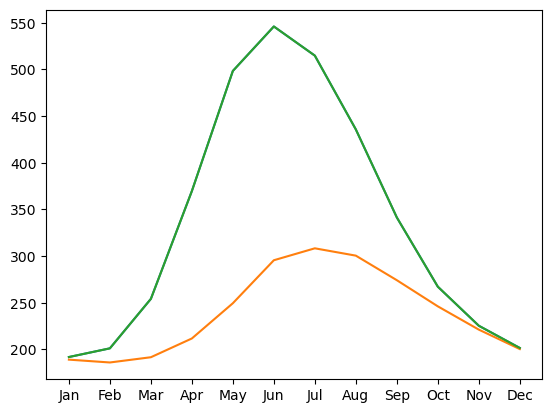

------------------Processing ACCESS-ESM1-5 1pctCO2------------------
Loading cubes...siconc...rsds...rlds...Done.
Calculating time series for...siconc...rsds...rlds...total...Done.
Calculating climatology for...siconc...rsds...rlds...total...Done.


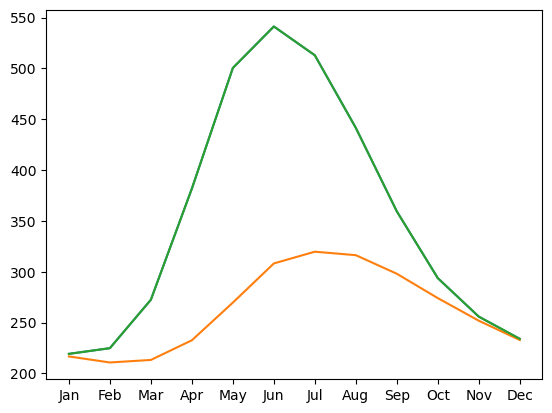

Calculating anomalies for...siconc...rsds...rlds...total...Done.
Calculating climatology for...siconc...rsds...rlds...total...Done.


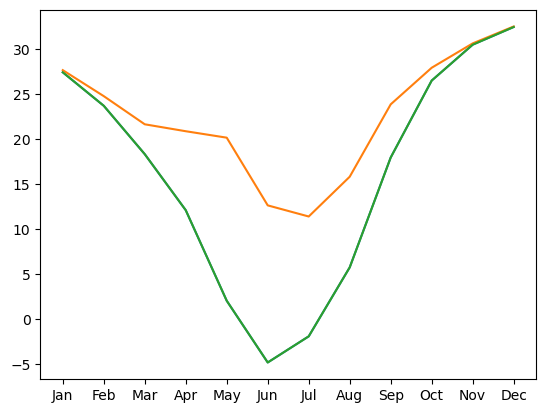

------------------Processing ACCESS-ESM1-5 lig127k------------------
Loading cubes...siconc...rsds...rlds...Done.
Calculating time series for...siconc...rsds...rlds...total...Done.
Calculating climatology for...siconc...rsds...rlds...total...Done.


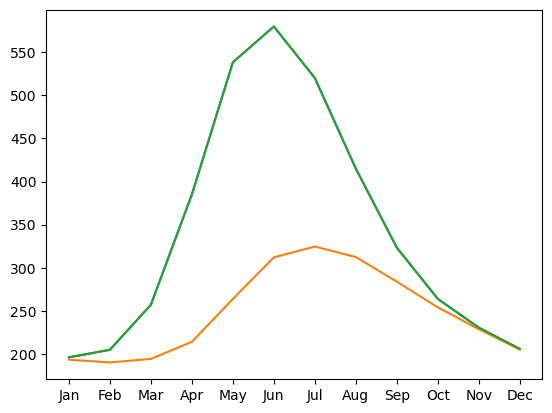

Calculating anomalies for...siconc...rsds...rlds...total...Done.
Calculating climatology for...siconc...rsds...rlds...total...Done.


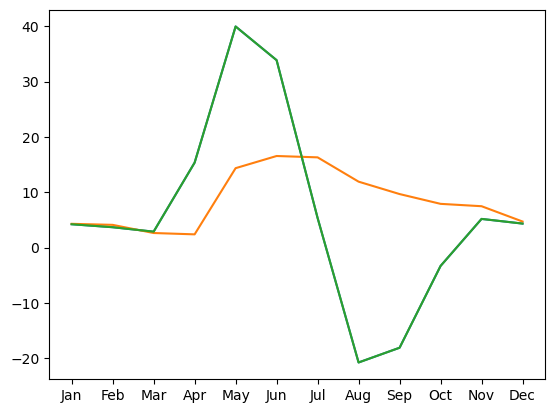

Predicted paleo siconc (from Gaussian fit): -1.5343128276802724
Actual paleo siconc (Sep anomaly): -2.98425938995708


In [52]:
models = ['ACCESS-ESM1-5']

transient_stats_dict = {}
paleo_predict_dict = {}
regression_method = 'linear_sum' #options: 'linear', 'ridge', 'linear_sum'
op = 'sum'

for model in models:
  print(f'------------------Processing {model} {control}------------------')
  control_cube_dict = get_cube_dict(model, control, var_list, root_path, con, shape)
  control_ts_dict = get_ts_dict_from_cube_dict(control_cube_dict, var_list, energy_var_dict)
  control_clim_dict = get_clim_dict_from_ts_dict(control_ts_dict)

  print(f'------------------Processing {model} {transient}------------------')
  transient_cube_dict = get_cube_dict(model, transient, var_list, root_path, con, shape)
  transient_ts_dict = get_ts_dict_from_cube_dict(transient_cube_dict, var_list, energy_var_dict)
  transient_clim_dict = get_clim_dict_from_ts_dict(transient_ts_dict)
  transient_anom_ts_dict = calculate_anomalies(transient_ts_dict, control_clim_dict)
  transient_anom_clim_dict = get_clim_dict_from_ts_dict(transient_anom_ts_dict)

  print(f'------------------Processing {model} {paleo}------------------')
  paleo_cube_dict = get_cube_dict(model, paleo, var_list, root_path, con, shape)
  paleo_ts_dict = get_ts_dict_from_cube_dict(paleo_cube_dict, var_list, energy_var_dict)
  paleo_clim_dict = get_clim_dict_from_ts_dict(paleo_ts_dict)
  paleo_anom_ts_dict = calculate_anomalies(paleo_ts_dict, control_clim_dict)
  paleo_anom_clim_dict = get_clim_dict_from_ts_dict(paleo_anom_ts_dict)

  energy_cube = transient_anom_ts_dict['rsds'][0:80*12]+transient_anom_ts_dict['rlds'][0:80*12] #
  sia_cube = transient_anom_ts_dict['siconc'].extract(iris.Constraint(month='Sep'))[0:80] / 1e14
  gaussian_fit = fit_gaussian_month_weights(energy_cube, sia_cube)


  guassian_weights = gaussian_fit['weights']
  guassian_scale = gaussian_fit['alpha']

  predicted_paleo_siconc = guassian_scale * np.sum(np.dot(guassian_weights, paleo_anom_clim_dict['rsds'].data + paleo_anom_clim_dict['rlds'].data))
  print("Predicted paleo siconc (from Gaussian fit):", predicted_paleo_siconc)
  print("Actual paleo siconc (Sep anomaly):", paleo_anom_clim_dict['siconc'].extract(iris.Constraint(month='Sep')).data / 1e14)
  
  # print(f'------------------{model} {transient}------------------')
  # transient_stats = plots_and_stats(transient_anom_ts_dict, regression = regression_method, op = op)
  # transient_stats_dict[model] = transient_stats
  # print(f'------------------{model} {paleo}------------------')


  
  # paleo_anom_clim_dict = get_clim_dict_from_ts_dict(paleo_anom_ts_dict)
  # paleo_mean_positive_rlds = get_annual_function(paleo_anom_clim_dict['rlds'], op=op)
  # paleo_mean_positive_rsds = get_annual_function(paleo_anom_clim_dict['rsds'], op=op)
  # paleo_sep_siconc_anom = paleo_anom_clim_dict['siconc'].extract(iris.Constraint(month='Sep'))

  # predicted_siconc = transient_stats[0] * (paleo_mean_positive_rsds + paleo_mean_positive_rlds) + transient_stats[1]
  # print("Predicted siconc (from transient regression):", predicted_siconc.data)
  # print("Actual paleo siconc (Sep anomaly):", paleo_sep_siconc_anom.data / 1e14)
  # paleo_predict_dict[model] = [paleo_sep_siconc_anom.data / 1e14, predicted_siconc.data]
  #paleo_stats_dict[model] = plots_and_stats(paleo_anom_ts_dict, regression = regression_method)

In [53]:

gaussian_fit

{'mu': np.float64(9.0),
 'sigma': np.float64(3.223450690053833),
 'alpha': np.float64(-0.12577129928280872),
 'weights': array([0.06127877, 0.03973972, 0.02340684, 0.03973972, 0.06127877,
        0.08582199, 0.10916676, 0.12612045, 0.13233778, 0.12612045,
        0.10916676, 0.08582199]),
 'predictor': array([ 0.1627663 , -0.14773188,  1.46222451, -7.37247091,  0.58723453,
        -2.09569808, -1.05754772, -1.16246739,  3.49442794,  5.76774176,
         8.0300397 ,  0.66698725,  7.86006429,  7.12856795,  7.06648539,
         5.82467853,  6.60642795, 10.4601037 ,  7.65714203,  6.73651827,
         5.91412283, 10.23101599,  7.47102809, 10.58494107, 12.51836669,
        16.92940755, 12.06164751, 12.36123794, 14.87198097, 12.52396337,
        11.29274469,  9.6731507 , 14.70283362, 15.35827557, 14.43511744,
        13.74705889, 17.84992327, 16.57623016, 16.81254111, 13.05557677,
        16.5835049 , 21.03867419, 20.17453292, 20.73701327, 22.10014609,
        23.48757408, 18.49860871, 15.254

ACCESS-ESM1-5: Predicted siconc = [-3.4932293], Actual paleo siconc = -2.98425938995708
CESM2: Predicted siconc = [-4.17599434], Actual paleo siconc = -3.8532462042909676
CNRM-CM6-1: Predicted siconc = [-3.01149873], Actual paleo siconc = -1.6298119253181498
IPSL-CM6A-LR: Predicted siconc = [-4.40619546], Actual paleo siconc = -3.6885724457717317


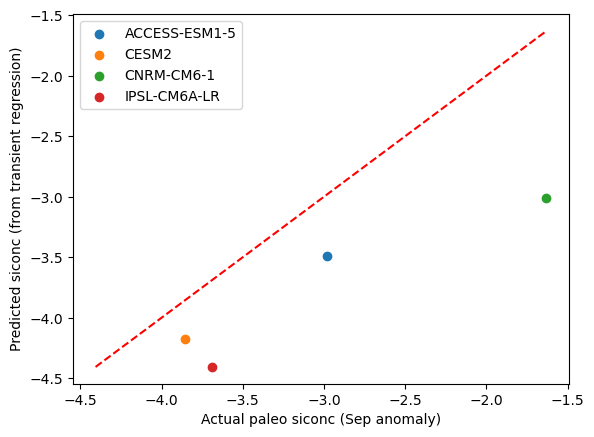

In [37]:
predicted_siconc_array = np.array([paleo_predict_dict[model][1] for model in models])
actual_siconc_array = np.array([paleo_predict_dict[model][0] for model in models])
for model in models:
    print(f"{model}: Predicted siconc = {paleo_predict_dict[model][1]}, Actual paleo siconc = {paleo_predict_dict[model][0]}")
    plt.scatter(paleo_predict_dict[model][0], paleo_predict_dict[model][1], label=model)
#add 1:1 line
max_val = max(predicted_siconc_array.max(), actual_siconc_array.max())
min_val = min(predicted_siconc_array.min(), actual_siconc_array.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.xlabel("Actual paleo siconc (Sep anomaly)")
plt.ylabel("Predicted siconc (from transient regression)")
plt.legend()
plt.show()


In [ ]:
#EC-Earth3 failed to download, try new wget from a different location